In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import spearmanr, kendalltau
from types import FunctionType
from pprint import pprint
import matplotlib.patches as mpatches

plt.style.use(["science", "grid", "ieee"])

In [15]:
DATASETS = [
    "fb-wosn-friends",
    "comm-linux-kernel-reply",
    "ia-enron-email-all",
]

SHORT_NAMES = {
    "fb-wosn-friends": "fb-wosn",
    "comm-linux-kernel-reply": "linux",
    "ia-enron-email-all": "enron",
}

TIME_STAMPS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
FILE_NAMES = {
    ds: {alpha: f"distances/{ds}_{int(alpha*100)}%" for alpha in TIME_STAMPS}
    for ds in DATASETS
}

FILE_NAMES

{'fb-wosn-friends': {0.5: 'distances/fb-wosn-friends_50%',
  0.6: 'distances/fb-wosn-friends_60%',
  0.7: 'distances/fb-wosn-friends_70%',
  0.8: 'distances/fb-wosn-friends_80%',
  0.9: 'distances/fb-wosn-friends_90%',
  1.0: 'distances/fb-wosn-friends_100%'},
 'comm-linux-kernel-reply': {0.5: 'distances/comm-linux-kernel-reply_50%',
  0.6: 'distances/comm-linux-kernel-reply_60%',
  0.7: 'distances/comm-linux-kernel-reply_70%',
  0.8: 'distances/comm-linux-kernel-reply_80%',
  0.9: 'distances/comm-linux-kernel-reply_90%',
  1.0: 'distances/comm-linux-kernel-reply_100%'},
 'ia-enron-email-all': {0.5: 'distances/ia-enron-email-all_50%',
  0.6: 'distances/ia-enron-email-all_60%',
  0.7: 'distances/ia-enron-email-all_70%',
  0.8: 'distances/ia-enron-email-all_80%',
  0.9: 'distances/ia-enron-email-all_90%',
  1.0: 'distances/ia-enron-email-all_100%'}}

In [16]:
def harmonic_centrality(layers: list[int | float], trunc: int = np.inf) -> np.ndarray:
    HC = np.zeros(len(layers))
    for u, layer in enumerate(layers):
        for d in range(1, len(layer)):
            if d > trunc:
                break
            HC[u] += layer[d] / d
    return HC

In [17]:
def top_vertices(HC: np.ndarray, k: int) -> list[int]:
    return [i for i, _ in sorted(enumerate(HC), key=lambda x: x[1], reverse=True)[:k]]

In [18]:
# def load_layers(
#     dataset: str, alpha: float = 1.0, apx: bool = False
# ) -> list[int | float]:
#     fname = FILE_NAMES[dataset][alpha] + (".dist" if not apx else ".apxdist")
#     with open(fname, "r") as f:
#         # return [list(map(int if not apx else float, l.split())) for l in f.readlines()]
#         if not apx:
#             return [list(map(int, l.split())) for l in f.readlines()]
#         else:
#             layers = [list(map(float, l.split())) for l in f.readlines()]
#             for i in range(len(layers)):
#                 layers[i][2] -= layers[i][1]
#             return layers

def load_layers(
    dataset: str, alpha: float = 1.0,
) -> list[int | float]:
    fname = FILE_NAMES[dataset][alpha] + ".dist"
    with open(fname, "r") as f:
        return [list(map(int, l.split())) for l in f.readlines()]

In [19]:
def truncated_harmonic_centrality(
    dataset: str,
    alpha: float = 1.0,
    p: float = 0.05,
) -> np.ndarray:
    layers = load_layers(dataset, alpha)
    hc = harmonic_centrality(layers)
    k = int(len(layers) * p)
    top_k = top_vertices(hc, k)

    diam = max([len(layers[i]) for i in top_k]) - 1

    M = np.zeros((k, diam))
    for i, u in enumerate(top_k):
        for d in range(len(layers[u]) - 1):
            M[i, d:] += layers[u][d + 1] / (d + 1)

    return M

In [20]:
def apx_centrality(dataset: str, alpha: float = 1.0) -> np.ndarray:
    """
    Compute the apx-truncated-harmonic centrality for the given `dataset`, at a given timestamp `alpha`.
    """
    layers = load_layers(dataset, alpha, apx=True)
    return harmonic_centrality(layers)

In [21]:
def correlation(
    centralities: np.ndarray, correlation_function: FunctionType = spearmanr
) -> list[float]:
    return [
        correlation_function(centralities[:, d], centralities[:, -1]).statistic
        for d in range(len(centralities[0]))
    ]

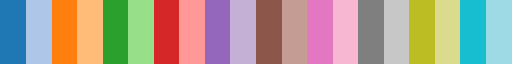

In [22]:
plt.cm.tab20

# PLOT4

In [23]:
def load_layers2(dataset: str, alpha: float = 1.0) -> list[list[tuple[int, int]]]:
    fname = FILE_NAMES[dataset][alpha] + ".apxdist"
    with open(fname, "r") as f:
        lines = [list(map(int, l.split())) for l in f.readlines()]
        layers = []
        for l in lines:
            layers.append([(l[i], l[i + 1]) for i in range(0, len(l), 2)])
        return layers


def hc2(dataset: str, alpha=1.0) -> np.ndarray[float]:
    layers = load_layers2(dataset, alpha)
    n = len(layers)
    n_run = len(layers[0])

    _l = load_layers(dataset, alpha)
    hc = harmonic_centrality(_l)
    trunc_hc = harmonic_centrality(_l, trunc=2)
    assert n == len(hc)

    ordered_vertices = [
        i for i, _ in sorted(enumerate(hc), key=lambda x: x[1], reverse=True)
    ]
    assert max(hc) == hc[ordered_vertices[0]]

    M = np.zeros((n, n_run + 2))
    # for u in ordered_vertices:
    #     l = layers[u]
    #     for i, (b1, b2) in enumerate(l):
    #         M[u, i] = b1 - 1 + (b2 - b1) / 2
    #     M[u, -2] = trunc_hc[u]
    #     M[u, -1] = hc[u]

    # M[:, -2] = trunc_hc[ordered_vertices,]
    # M[:, -1] = hc[ordered_vertices,]

    for u, layer in enumerate(layers):
        for i, (b1, b2) in enumerate(layer):
            M[u, i] = b1 - 1 + (b2 - b1) / 2
        M[u, -2] = trunc_hc[u]
        M[u, -1] = hc[u]
        
    return M[ordered_vertices,]

m = hc2(DATASETS[0])

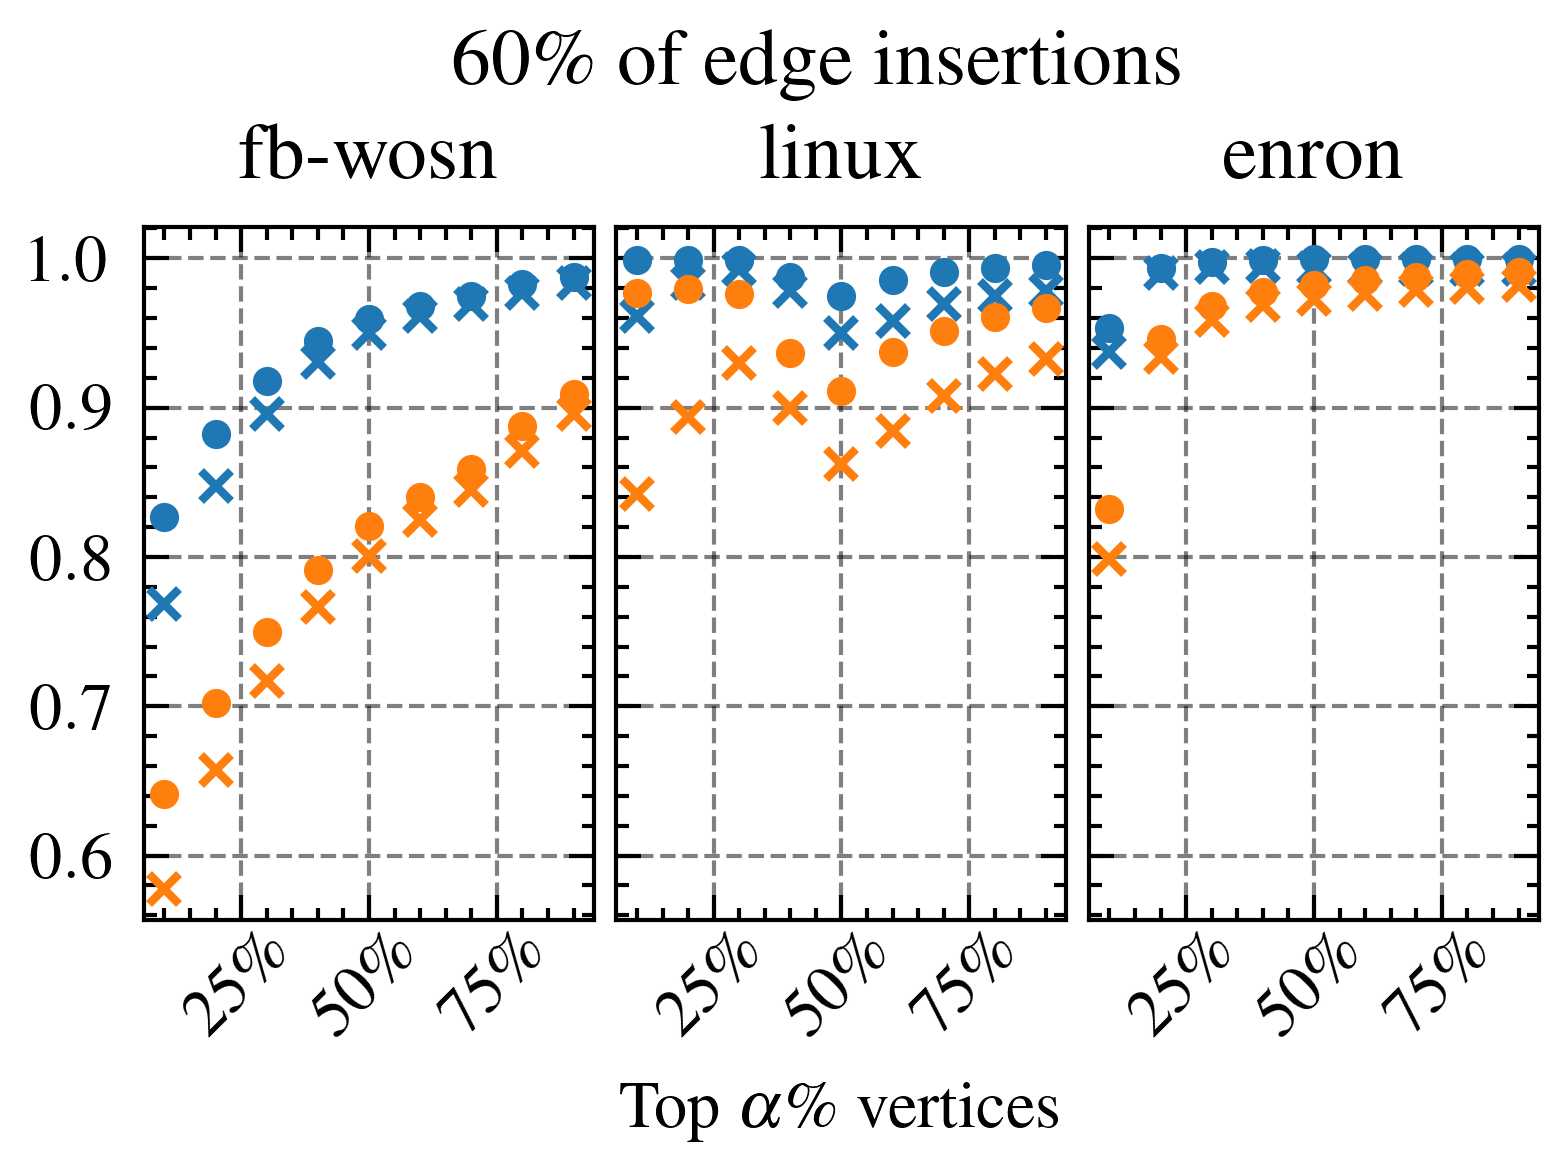

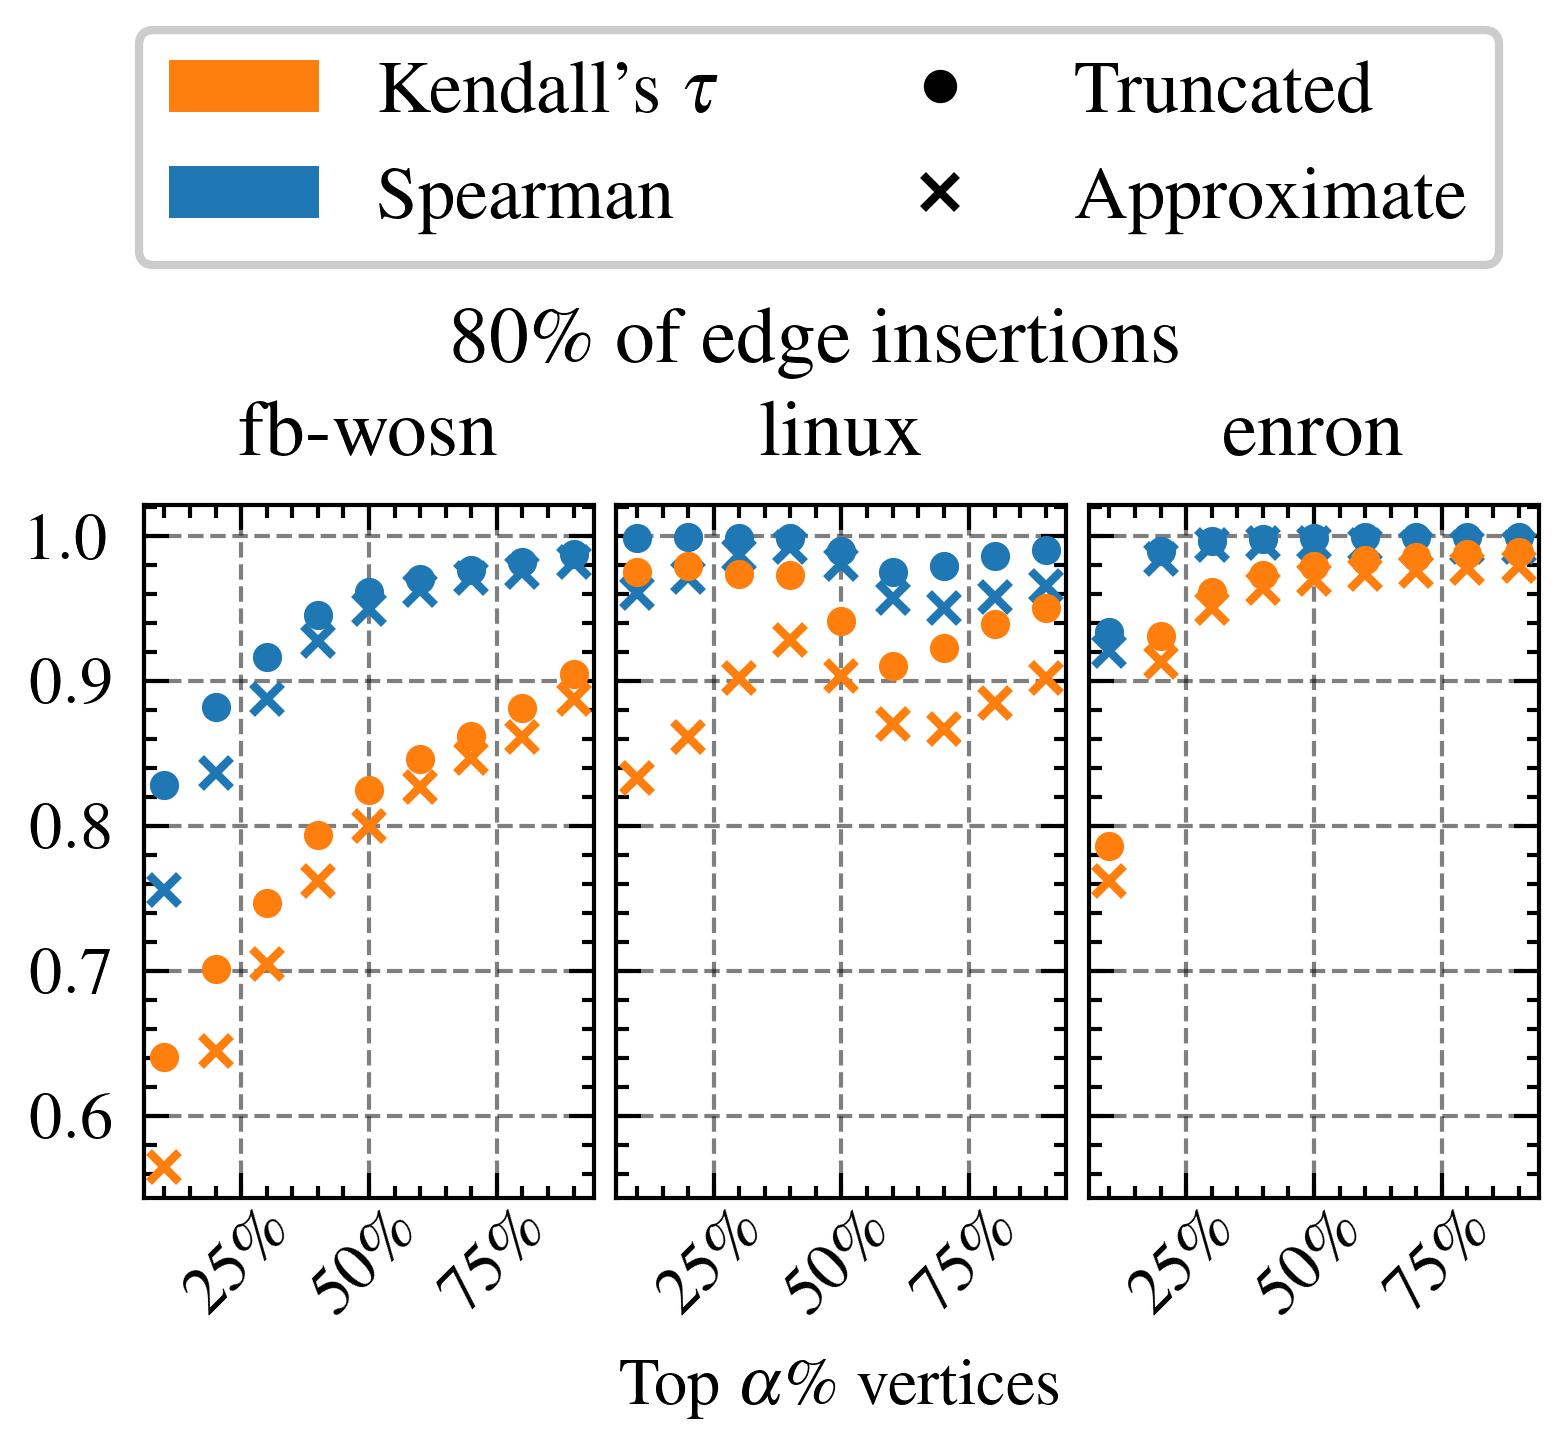

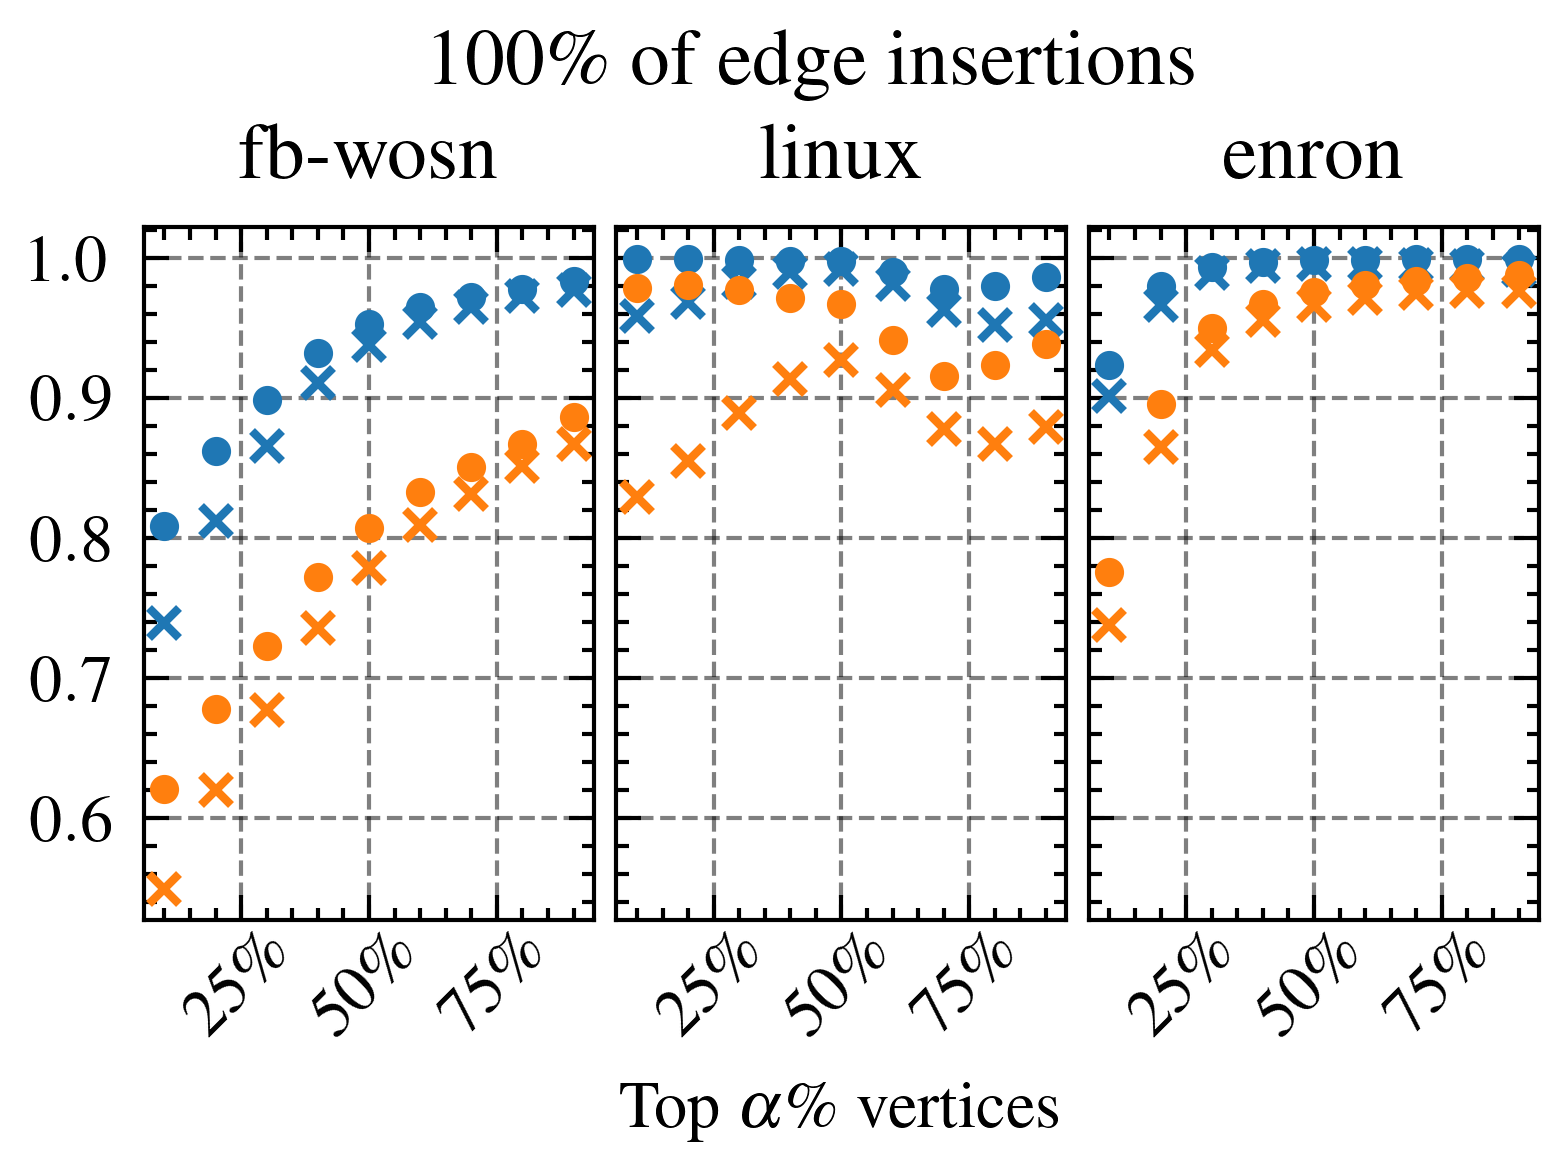

In [24]:
def plot4(alpha: float, doLegend: bool = False):

    ps = np.linspace(0.0, 1, 10)
    fig, ax = plt.subplots(1, 3, figsize=(3, 1.5), sharey=True)
    fig.subplots_adjust(hspace=0.25, wspace=0.05)

    lw = 0.6
    ms = 5

    for i, ds in enumerate(DATASETS):
        ax[i].set_title(SHORT_NAMES[ds])

        y1, y2, y3, y4 = [], [], [], []
        H = hc2(ds, alpha)
        n, cols = H.shape
        cols -= 2

        hc = H[:, -1]
        trunc_hc = H[:, -2]

        assert len(hc) == n

        for p in ps:
            k = int(n * p)
            s1, s2 = 0, 0
            for c in range(cols):
                s1 += spearmanr(hc[:k], H[:k, c]).statistic
                s2 += kendalltau(hc[:k], H[:k, c]).statistic
            s1 /= cols
            s2 /= cols

            y1.append(s1)
            y2.append(s2)

            y3.append(spearmanr(hc[:k], trunc_hc[:k]).statistic)
            y4.append(kendalltau(hc[:k], trunc_hc[:k]).statistic)

        ax[i].plot(
            y1,
            color="tab:blue",
            marker="x",
            markersize=3.5,
            linestyle="",
            linewidth=lw,
        )

        ax[i].plot(
            y2,
            color="tab:orange",
            marker="x",
            markersize=3.5,
            linestyle="",
            linewidth=lw,
        )

        ax[i].plot(
            y3,
            color="tab:blue",
            marker=".",
            markersize=ms,
            linestyle="",
            linewidth=lw,
        )

        ax[i].plot(
            y4,
            color="tab:orange",
            marker=".",
            markersize=ms,
            linestyle="",
            linewidth=lw,
        )

        ax[i].set_xticks([2.5, 5, 7.5], [f"{int(x*100)}\%" for x in [0.25, 0.5, 0.75]])
        ax[i].tick_params(axis="x", rotation=45, pad=0)

    ax[1].set_xlabel("Top $\\alpha$\% vertices")

    if doLegend:
        fig.legend(
            handles=[
                mpatches.Patch(
                    label="Kendall's $\\tau$",
                    facecolor="tab:orange",
                    linewidth=4,
                ),
                mpatches.Patch(
                    label="Spearman",
                    facecolor="tab:blue",
                    linewidth=4,
                ),
                plt.Line2D(
                    [0],
                    [0],
                    label="Truncated",
                    marker=".",
                    linestyle="",
                    color="k",
                ),
                plt.Line2D(
                    [0],
                    [0],
                    label="Approximate",
                    marker="x",
                    markersize=4,
                    linestyle="",
                    color="k",
                ),
            ],
            loc="upper center",
            ncol=2,
            # bbox_to_anchor=(0.5, 1.05),
            bbox_to_anchor=(0.5, 1.45),
            fontsize=9,
        )

    fig.suptitle(
        f"{int(alpha*100)}\% of edge insertions",
        # fontsize=8,
        y=1.1,
    )

    plt.show()
    # plt.savefig(f"./correlation_{int(alpha*100)}.pdf")


plot4(0.6)
plot4(0.8, True)
plot4(1)

# PLOT 5

0.7152276295133438
0.7602636534839925
0.8266907265024322
0.6891679748822606
0.7572504708097928
0.815189078926722
0.6875981161695448
0.7412115505335843
0.7934096971598933
0.9017921146953407
0.9334527220630374
0.950214899713467
0.8953405017921148
0.9303724928366762
0.9326289398280803
0.8881720430107526
0.927865329512894
0.9371776504297994
0.8504587155963301
0.8920238368095348
0.9970207402314657
0.8767201834862386
0.8394224157689664
0.9319812077460755
0.8827981651376147
0.8549163419665369
0.9249226538329323


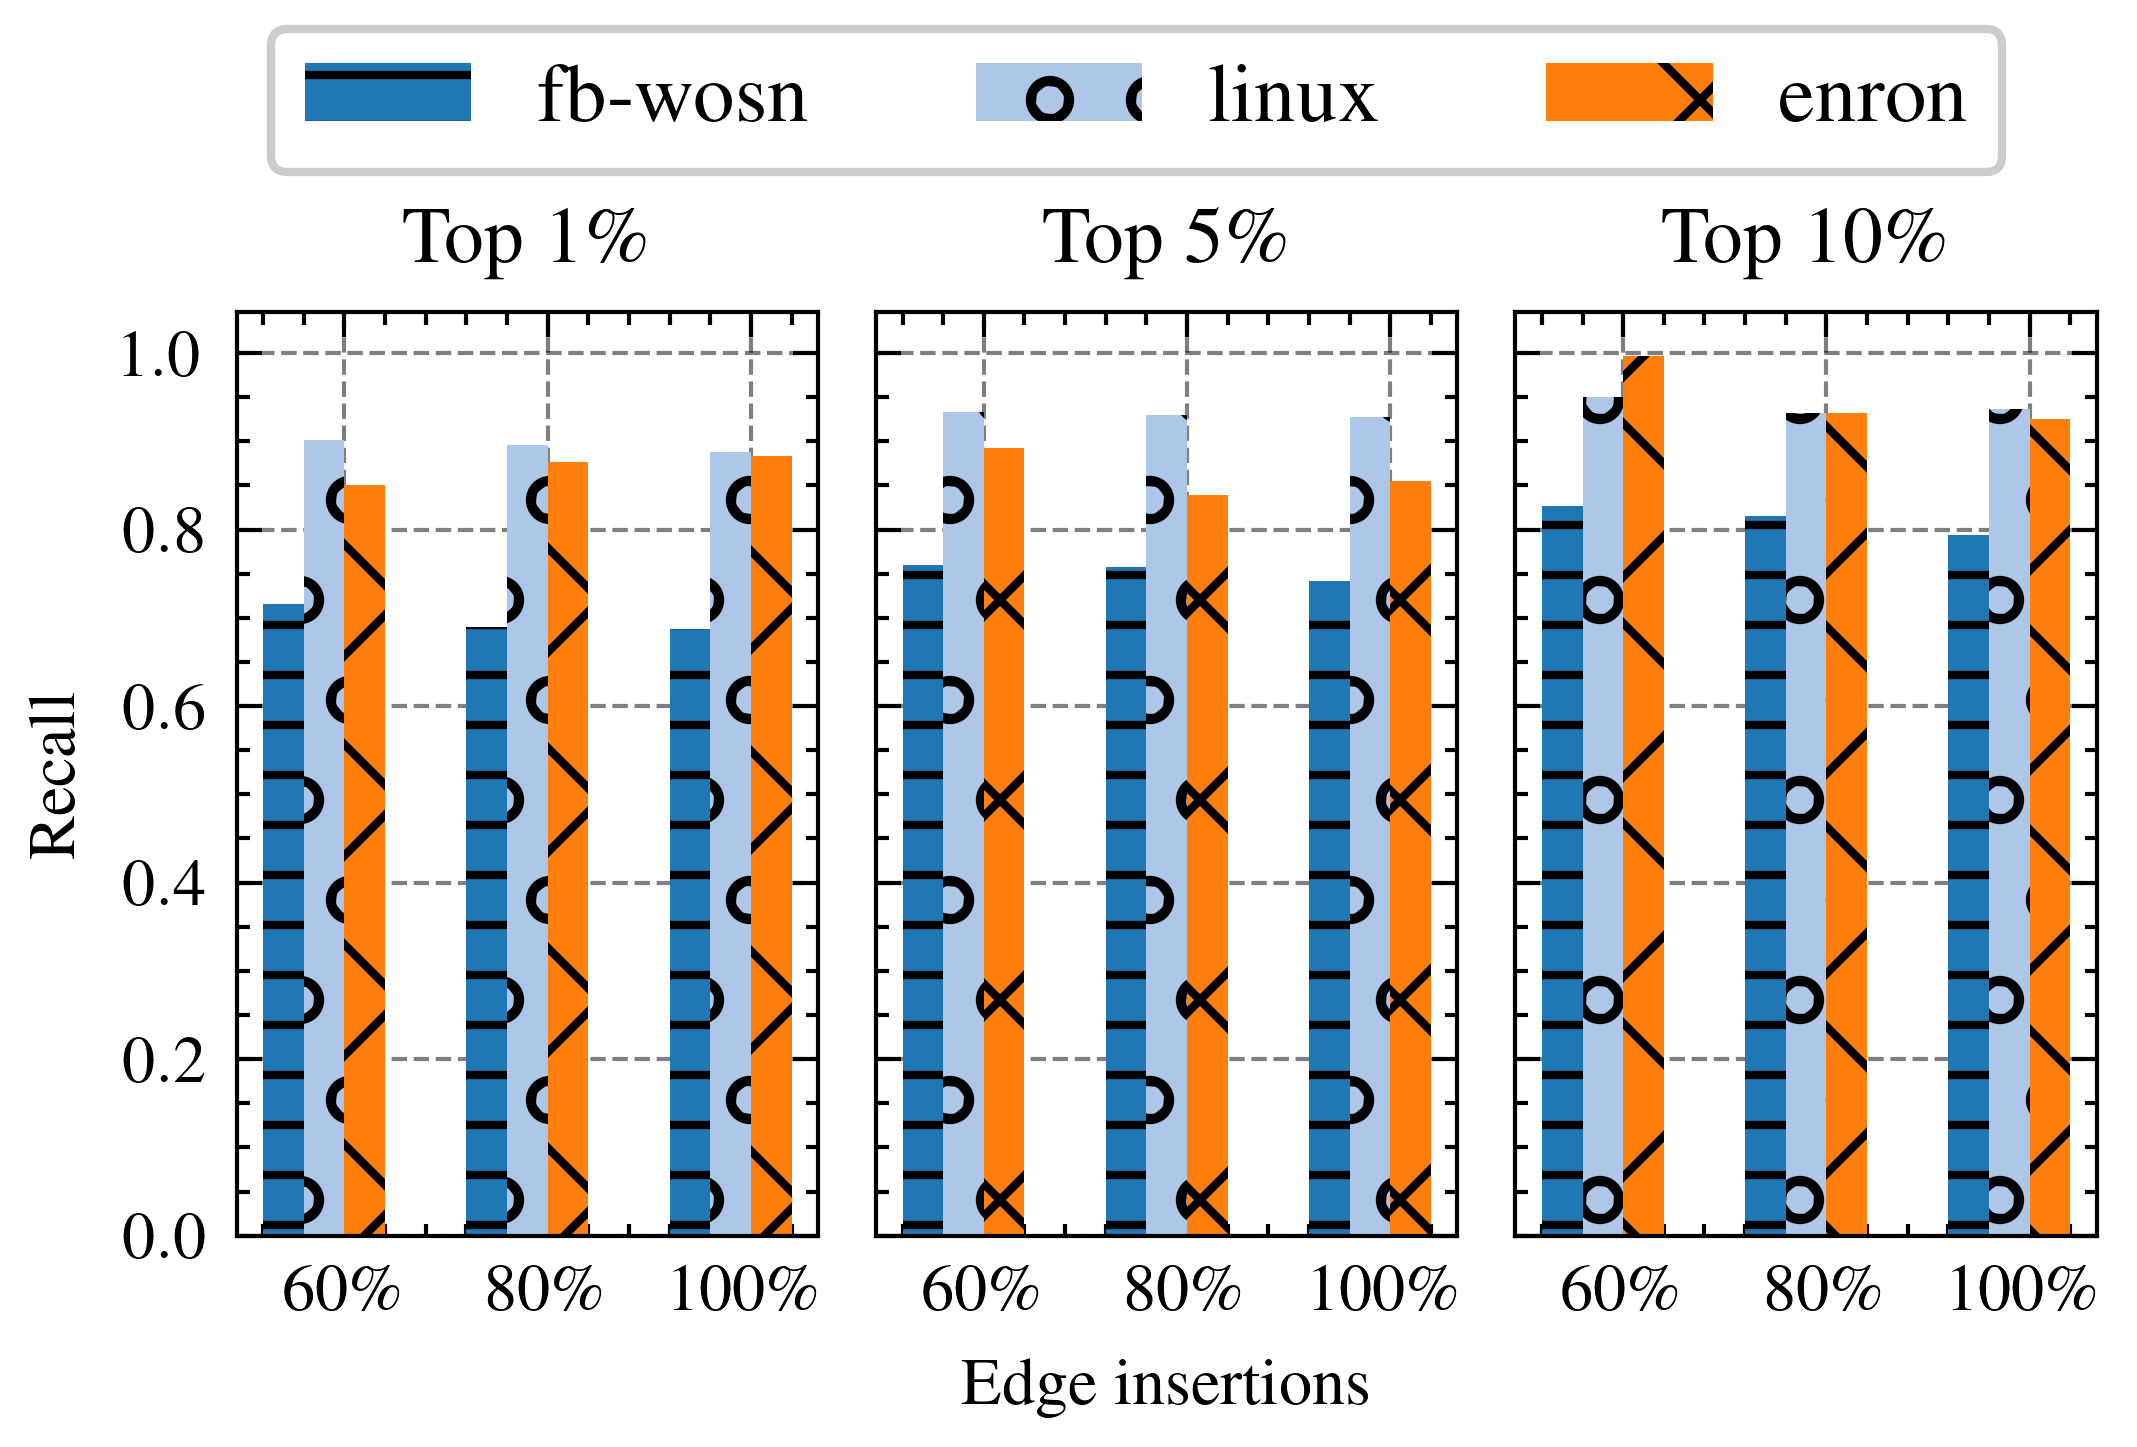

In [25]:
ps = [0.01, 0.05, 0.1]
time_stamps = [0.6, 0.8, 1.0]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(4, 2), sharey=True)
fig.subplots_adjust(wspace=0.1)

p = 0.05
recall = lambda eff, ret: len(set(eff) & set(ret)) / len(eff)
jaccard = lambda eff, ret: len(set(eff) & set(ret)) / len(set(eff) | set(ret))

w = 0.2
x = np.array(list(range(len(time_stamps))))

colors = plt.cm.tab20.colors[:4]
offsets = [-3 / 2, -1 / 2, 1 / 2, 3 / 2]
hatch = ["--", "o", "x", ".."]


for i, ds in enumerate(DATASETS):
    for k, alpha in enumerate(time_stamps):
        H = hc2(ds, alpha)
        _, cols = H.shape
        hc = [
            i for i, _ in sorted(enumerate(H[:, -1]), key=lambda x: x[1], reverse=True)
        ]

        ranks = [
            [i for i, _ in sorted(enumerate(H[:, c]), key=lambda x: x[1], reverse=True)]
            for c in range(cols - 2)
        ]

        for j, p in enumerate(ps):
            n = len(hc)

            y = 0
            for rank in ranks:
                y += recall(
                    hc[: int(p * n)],
                    rank[: int(p * n)],
                )
            y /= len(ranks)
            print(y)

            ax[j].bar(
                x[k] + w * offsets[i],
                y,
                width=w,
                color=colors[i],
                hatch=hatch[i],
            )

            ax[j].set_title(f"Top {int(p*100)}\%")
            ax[j].set_xticks([0, 1, 2], ["60\%", "80\%", "100\%"])

ax[0].set_ylabel("Recall")
ax[1].set_xlabel("Edge insertions")

fig.legend(
    handles=[
        # plt.Line2D(
        mpatches.Patch(
            label=SHORT_NAMES[ds],
            facecolor=colors[i],
            linewidth=2,
            # color=colors[i],
            hatch=hatch[i],
        )
        for i, ds in enumerate(DATASETS)
    ],
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.15),
    # fontsize=7,
    fontsize=10,
)

plt.show()
# plt.savefig("./recall_approximate.pdf")

# PLOT 6

0.7582417582417582
0.802887633396108
0.8476384748156285
0.7441130298273155
0.8097928436911488
0.8454417072022595
0.7472527472527473
0.7919020715630886
0.8297505099639102
0.985663082437276
0.9906876790830945
0.9960601719197708
0.982078853046595
0.9892550143266475
0.9899713467048711
0.978494623655914
0.9914040114613181
0.9946275071633238
0.875
0.9021315608526244
1.0
0.9094036697247706
0.8429979371991749
0.9334250028646729
0.9311926605504587
0.8785239514095806
0.9373209579466025


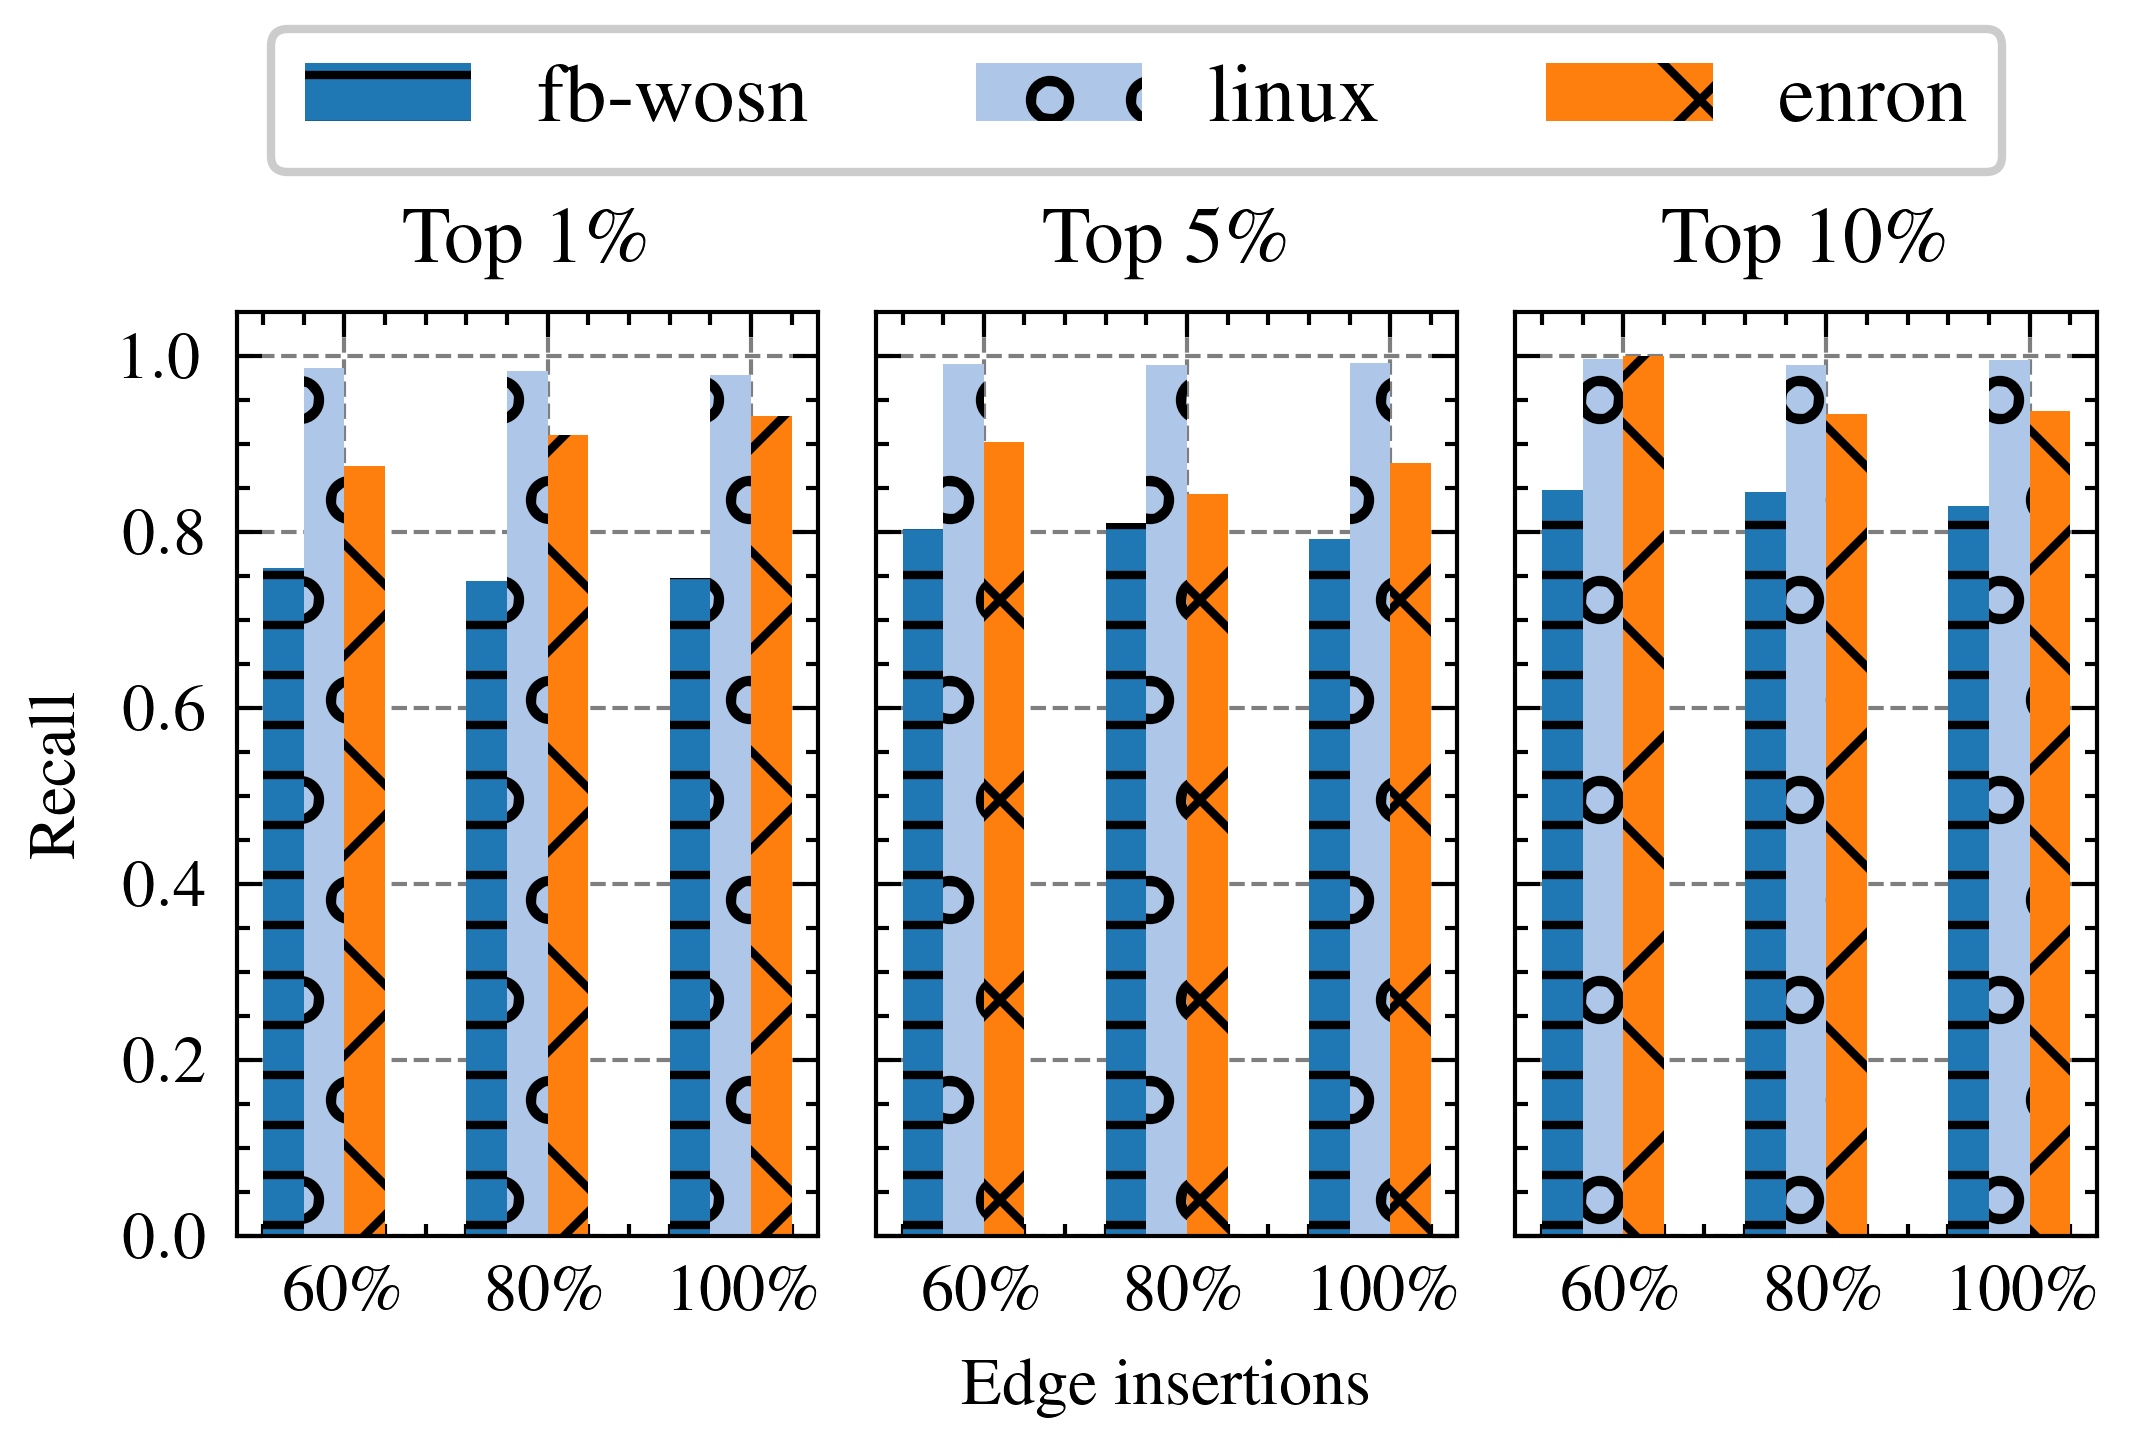

In [26]:
ps = [0.01, 0.05, 0.1]
time_stamps = [0.6, 0.8, 1.0]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(4, 2), sharey=True)
fig.subplots_adjust(wspace=0.1)

p = 0.05
recall = lambda eff, ret: len(set(eff) & set(ret)) / len(eff)
jaccard = lambda eff, ret: len(set(eff) & set(ret)) / len(set(eff) | set(ret))

w = 0.2
x = np.array(list(range(len(time_stamps))))

colors = plt.cm.tab20.colors[:4]
offsets = [-3 / 2, -1 / 2, 1 / 2, 3 / 2]
hatch = ["--", "o", "x", ".."]


for i, ds in enumerate(DATASETS):
    for k, alpha in enumerate(time_stamps):
        H = hc2(ds, alpha)
        _, cols = H.shape
        hc = [
            i for i, _ in sorted(enumerate(H[:, -1]), key=lambda x: x[1], reverse=True)
        ]

        trunc_hc = [
            i for i, _ in sorted(enumerate(H[:, -2]), key=lambda x: x[1], reverse=True)
        ]

        for j, p in enumerate(ps):
            n = len(hc)

            y = recall(
                hc[: int(p * n)],
                trunc_hc[: int(p * n)],
            )
            print(y)

            ax[j].bar(
                x[k] + w * offsets[i],
                y,
                width=w,
                color=colors[i],
                hatch=hatch[i],
            )

            ax[j].set_title(f"Top {int(p*100)}\%")
            ax[j].set_xticks([0, 1, 2], ["60\%", "80\%", "100\%"])

ax[0].set_ylabel("Recall")
ax[1].set_xlabel("Edge insertions")

fig.legend(
    handles=[
        # plt.Line2D(
        mpatches.Patch(
            label=SHORT_NAMES[ds],
            facecolor=colors[i],
            linewidth=2,
            # color=colors[i],
            hatch=hatch[i],
        )
        for i, ds in enumerate(DATASETS)
    ],
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.15),
    # fontsize=7,
    fontsize=10,
)

plt.show()
# plt.savefig("./recall_truncated.pdf")